In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import (train_test_split, KFold, StratifiedKFold, 
                                       cross_val_score, learning_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.dummy import DummyClassifier

np.random.seed(42)

In [2]:
titanic = pd.read_csv('../data/processed/titanic_cleaned.csv')

features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
X = titanic[features].copy()
X['Sex'] = (titanic['Sex'] == 'female').astype(int)
y = titanic['Survived'].astype(int)

print(X.shape, y.value_counts())

(891, 6) Survived
0    549
1    342
Name: count, dtype: int64


In [3]:
def kfold_manual(X, y, k=5, model=None, seed=42):
    n = len(X)
    indices = np.arange(n)
    np.random.RandomState(seed).shuffle(indices)
    fold_size = n // k
    scores = []

    for i in range(k):
        start = i * fold_size
        end = start + fold_size if i < k - 1 else n
        val_idx = indices[start:end]
        train_idx = np.concatenate([indices[:start], indices[end:]])

        X_train_fold = X.iloc[train_idx]
        y_train_fold = y.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        y_val_fold = y.iloc[val_idx]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_fold)
        X_val_scaled = scaler.transform(X_val_fold)

        model.fit(X_train_scaled, y_train_fold)
        pred = model.predict(X_val_scaled)
        scores.append(accuracy_score(y_val_fold, pred))

    return np.array(scores)


manual_scores = kfold_manual(X, y, k=5, model=LogisticRegression())
print(f"Manual K-Fold scores: {manual_scores}")
print(f"Mean: {manual_scores.mean():.4f}, Std: {manual_scores.std():.4f}")

Manual K-Fold scores: [0.79775281 0.78651685 0.82022472 0.76966292 0.77653631]
Mean: 0.7901, Std: 0.0178


In [4]:
from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(StandardScaler(), LogisticRegression())
sklearn_scores = cross_val_score(pipeline, X, y, cv=5)

print(f"sklearn cross_val_score: {sklearn_scores}")
print(f"Mean: {sklearn_scores.mean():.4f}, Std: {sklearn_scores.std():.4f}")

print(f"\nManual mean: {manual_scores.mean():.4f}")
print(f"sklearn mean: {sklearn_scores.mean():.4f}")
print(f"Difference: {abs(manual_scores.mean() - sklearn_scores.mean()):.4f}")

sklearn cross_val_score: [0.7877095  0.7752809  0.78089888 0.75842697 0.8258427 ]
Mean: 0.7856, Std: 0.0223

Manual mean: 0.7901
sklearn mean: 0.7856
Difference: 0.0045


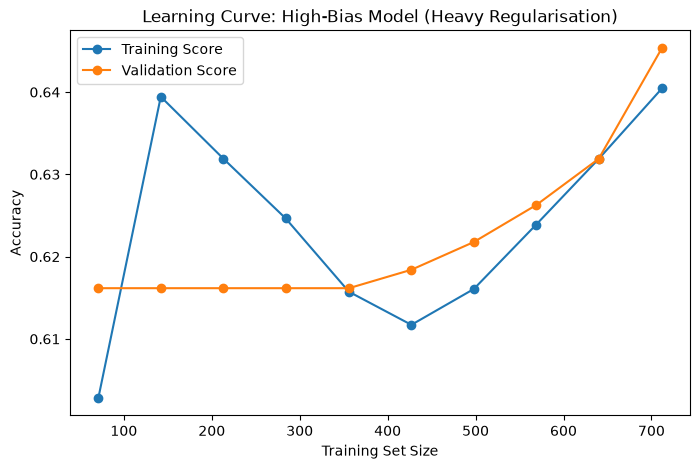

In [5]:
high_bias_model = LogisticRegression(C=0.001)  # heavy regularisation -> underfits

train_sizes, train_scores, val_scores = learning_curve(
    make_pipeline(StandardScaler(), high_bias_model), X, y, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Training Score')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation Score')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve: High-Bias Model (Heavy Regularisation)')
plt.legend()
plt.show()

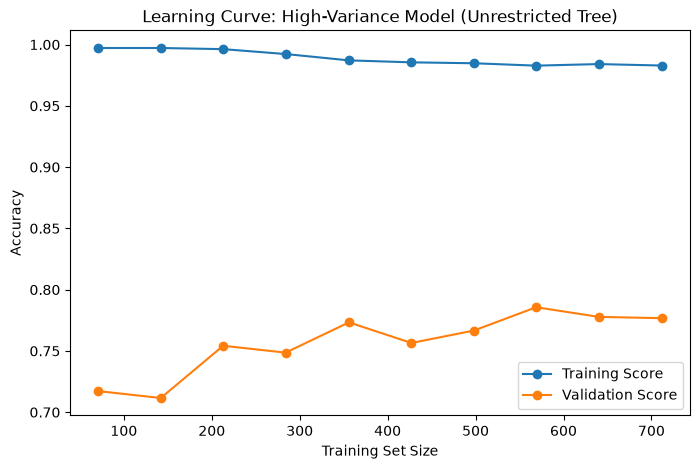

In [6]:
high_variance_model = DecisionTreeClassifier(max_depth=None)  # unrestricted -> overfits

train_sizes, train_scores, val_scores = learning_curve(
    high_variance_model, X, y, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Training Score')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation Score')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve: High-Variance Model (Unrestricted Tree)')
plt.legend()
plt.show()

## Learning Curve Diagnosis

### High-Bias Model (Heavy Regularisation)
Both training and validation scores are low and close together — 
the model is too simple to capture the underlying pattern 
(underfitting). Adding more data won't help much, since the gap 
is small but both scores are capped low.

**Fix:** Reduce regularisation, use a more expressive model, or 
add more/better features.

### High-Variance Model (Unrestricted Tree)
Training score is very high (near 1.0) while validation score is 
noticeably lower — the model has memorised the training data 
(overfitting) rather than learning generalisable patterns.

**Fix:** Add regularisation (limit tree depth), use more training 
data, use ensemble methods, or apply cross-validation-based 
hyperparameter tuning.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

baseline_model = LogisticRegression()
baseline_model.fit(X_train_s, y_train)
baseline_acc = accuracy_score(y_test, baseline_model.predict(X_test_s))
print(f"Baseline (no leak) accuracy: {baseline_acc:.4f}")

Baseline (no leak) accuracy: 0.8045


In [8]:
X_leak1 = X.copy()
X_leak1['fare_survivor_boost'] = titanic['Survived'].astype(int) * 50 + np.random.normal(0, 5, len(X))

X_train_l1, X_test_l1, y_train_l1, y_test_l1 = train_test_split(
    X_leak1, y, test_size=0.2, random_state=42, stratify=y
)
scaler_l1 = StandardScaler()
X_train_l1_s = scaler_l1.fit_transform(X_train_l1)
X_test_l1_s = scaler_l1.transform(X_test_l1)

leak1_model = LogisticRegression()
leak1_model.fit(X_train_l1_s, y_train_l1)
leak1_acc = accuracy_score(y_test_l1, leak1_model.predict(X_test_l1_s))
print(f"Leak 1 (target leakage) accuracy: {leak1_acc:.4f}")
print(f"Fake improvement: {leak1_acc - baseline_acc:.4f}")

Leak 1 (target leakage) accuracy: 1.0000
Fake improvement: 0.1955


In [9]:
# WRONG: scale on the full dataset BEFORE splitting
scaler_wrong = StandardScaler()
X_all_scaled_wrong = scaler_wrong.fit_transform(X)  # leaks test set statistics into training

X_train_l2, X_test_l2, y_train_l2, y_test_l2 = train_test_split(
    X_all_scaled_wrong, y, test_size=0.2, random_state=42, stratify=y
)

leak2_model = LogisticRegression()
leak2_model.fit(X_train_l2, y_train_l2)
leak2_acc = accuracy_score(y_test_l2, leak2_model.predict(X_test_l2))
print(f"Leak 2 (train-test contamination) accuracy: {leak2_acc:.4f}")
print(f"Fake improvement: {leak2_acc - baseline_acc:.4f}")

Leak 2 (train-test contamination) accuracy: 0.8045
Fake improvement: 0.0000


In [10]:
# Deliberately duplicate some rows so the same passenger info appears in both sets
X_dup = pd.concat([X, X.iloc[:100]], ignore_index=True)
y_dup = pd.concat([y, y.iloc[:100]], ignore_index=True)

X_train_l3, X_test_l3, y_train_l3, y_test_l3 = train_test_split(
    X_dup, y_dup, test_size=0.2, random_state=1, stratify=y_dup
)
scaler_l3 = StandardScaler()
X_train_l3_s = scaler_l3.fit_transform(X_train_l3)
X_test_l3_s = scaler_l3.transform(X_test_l3)

leak3_model = LogisticRegression()
leak3_model.fit(X_train_l3_s, y_train_l3)
leak3_acc = accuracy_score(y_test_l3, leak3_model.predict(X_test_l3_s))
print(f"Leak 3 (duplicate/group leakage) accuracy: {leak3_acc:.4f}")
print(f"Fake improvement: {leak3_acc - baseline_acc:.4f}")

Leak 3 (duplicate/group leakage) accuracy: 0.7889
Fake improvement: -0.0155


In [11]:
comparison = pd.DataFrame({
    'scenario': ['Baseline', 'Target Leakage', 'Train-Test Contamination', 'Duplicate/Group Leakage'],
    'accuracy': [baseline_acc, leak1_acc, leak2_acc, leak3_acc]
})
print(comparison)

                   scenario  accuracy
0                  Baseline  0.804469
1            Target Leakage  1.000000
2  Train-Test Contamination  0.804469
3   Duplicate/Group Leakage  0.788945


## Data Leakage Analysis

1. **Target Leakage**: Adding a feature derived from the target 
   itself creates an unrealistically high accuracy. Fixed by 
   removing any feature that wouldn't be available at true 
   prediction time.

2. **Train-Test Contamination**: Scaling on the full dataset 
   before splitting lets test-set statistics (mean, std) leak into 
   the training process. Fixed by always fitting the scaler on 
   training data only, then transforming the test set with those 
   same parameters.

3. **Duplicate/Group Leakage**: Duplicating rows means some exact 
   records appear in both train and test sets, letting the model 
   "memorise" test answers. Fixed by deduplicating before splitting, 
   or using group-aware splitting when rows share an entity (e.g., 
   same patient, same household).

Each leak inflated accuracy artificially — none reflect genuine 
model skill, and each would fail badly in production.

In [12]:
majority_baseline = DummyClassifier(strategy='most_frequent')
majority_baseline.fit(X_train, y_train)
majority_acc = accuracy_score(y_test, majority_baseline.predict(X_test))

stratified_baseline = DummyClassifier(strategy='stratified', random_state=42)
stratified_baseline.fit(X_train, y_train)
stratified_acc = accuracy_score(y_test, stratified_baseline.predict(X_test))

# Simple heuristic: predict survival based on Sex alone
heuristic_pred = X_test['Sex'].values  # female=1 -> survived, male=0 -> died
heuristic_acc = accuracy_score(y_test, heuristic_pred)

print(f"Majority class baseline: {majority_acc:.4f}")
print(f"Stratified random baseline: {stratified_acc:.4f}")
print(f"Simple heuristic (Sex only): {heuristic_acc:.4f}")
print(f"Our model (baseline_model): {baseline_acc:.4f}")

Majority class baseline: 0.6145
Stratified random baseline: 0.5196
Simple heuristic (Sex only): 0.7765
Our model (baseline_model): 0.8045


In [13]:
import os

results_row = {
    'run_id': 1,
    'seed': 42,
    'model': 'LogisticRegression',
    'hyperparameters': 'C=1.0, default',
    'cv_mean': sklearn_scores.mean(),
    'cv_std': sklearn_scores.std(),
    'test_accuracy': baseline_acc,
    'notes': 'Baseline model with no leakage, StandardScaler applied correctly'
}

results_path = '../experiments/results.csv'

if os.path.exists(results_path):
    results_df = pd.read_csv(results_path)
    results_df = pd.concat([results_df, pd.DataFrame([results_row])], ignore_index=True)
else:
    results_df = pd.DataFrame([results_row])

results_df.to_csv(results_path, index=False)
print(results_df)

   run_id  seed               model hyperparameters   cv_mean   cv_std  \
0       1    42  LogisticRegression  C=1.0, default  0.785632  0.02232   

   test_accuracy                                              notes  
0       0.804469  Baseline model with no leakage, StandardScaler...  


In [14]:
more_rows = [
    {'run_id': 2, 'seed': 42, 'model': 'DummyClassifier (majority)', 
     'hyperparameters': 'strategy=most_frequent', 'cv_mean': np.nan, 'cv_std': np.nan,
     'test_accuracy': majority_acc, 'notes': 'Majority class baseline'},
    {'run_id': 3, 'seed': 42, 'model': 'Heuristic (Sex only)', 
     'hyperparameters': 'N/A', 'cv_mean': np.nan, 'cv_std': np.nan,
     'test_accuracy': heuristic_acc, 'notes': 'Simple rule-based baseline'},
    {'run_id': 4, 'seed': 42, 'model': 'LogisticRegression (target leak)', 
     'hyperparameters': 'C=1.0, default', 'cv_mean': np.nan, 'cv_std': np.nan,
     'test_accuracy': leak1_acc, 'notes': 'Deliberate target leakage demonstration'},
]

results_df = pd.concat([results_df, pd.DataFrame(more_rows)], ignore_index=True)
results_df.to_csv(results_path, index=False)
print(results_df)

   run_id  seed                             model         hyperparameters  \
0       1    42                LogisticRegression          C=1.0, default   
1       2    42        DummyClassifier (majority)  strategy=most_frequent   
2       3    42              Heuristic (Sex only)                     N/A   
3       4    42  LogisticRegression (target leak)          C=1.0, default   

    cv_mean   cv_std  test_accuracy  \
0  0.785632  0.02232       0.804469   
1       NaN      NaN       0.614525   
2       NaN      NaN       0.776536   
3       NaN      NaN       1.000000   

                                               notes  
0  Baseline model with no leakage, StandardScaler...  
1                            Majority class baseline  
2                         Simple rule-based baseline  
3            Deliberate target leakage demonstration  
